# Classificação: Primeiros passos

Neste projeto, iremos analisar dados de uma campanha de marketing para aderência de investimentos. O intuito é usar as informações dos dados para prever se os clientes de um banco vão aplicar o dinheiro em um investimento ou não.

Essa previsão será feita utilizando machine learning e este notebook vai conter os passos para se obter um modelo capaz de realizar as previsões, desde a **leitura**, **análise exploratória**, **separação** e **transformação** dos dados, até o **ajuste**, **avaliação** e **comparação** de modelos de classificação.

# Análise exploratória

## Fazendo a leitura dos dados

Podemos realizar a leitura dos dados a partir da biblioteca `pandas`. Por conta disso, vamos realizar a importação da biblioteca com o comando `import pandas as pd`.

Como o arquivo de dados está no formato *csv*, vamos realizar a leitura com a função [`read_csv()`](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html).

In [1]:
import pandas as pd


In [2]:
df = pd.read_csv("marketing_investimento.csv")
df

,idade,estado_civil,escolaridade,inadimplencia,saldo,fez_emprestimo,tempo_ult_contato,numero_contatos,aderencia_investimento
0,45,casado (a),superior,nao,242,nao,587,1,sim
1,42,casado (a),medio,nao,1289,nao,250,4,sim
2,23,solteiro (a),superior,nao,363,nao,16,18,nao
3,58,divorciado (a),superior,nao,1382,nao,700,1,sim
4,50,casado (a),medio,nao,3357,nao,239,4,sim
...,...,...,...,...,...,...,...,...,...
1263,52,solteiro (a),superior,nao,83,nao,1223,6,sim
1264,35,solteiro (a),superior,nao,5958,nao,215,1,sim
1265,30,solteiro (a),superior,nao,-477,sim,1532,2,sim
1266,42,casado (a),superior,nao,2187,nao,525,3,sim


Para criar modelos de classificação, precisamos utilizar dados de qualidade, sem inconsistências e sem dados faltantes. Vamos checar se existem dados nulos e o tipo dos dados de cada coluna na base de dados a partir do método [`info()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.info.html).

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1268 entries, 0 to 1267
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   idade                   1268 non-null   int64 
 1   estado_civil            1268 non-null   object
 2   escolaridade            1268 non-null   object
 3   inadimplencia           1268 non-null   object
 4   saldo                   1268 non-null   int64 
 5   fez_emprestimo          1268 non-null   object
 6   tempo_ult_contato       1268 non-null   int64 
 7   numero_contatos         1268 non-null   int64 
 8   aderencia_investimento  1268 non-null   object
dtypes: int64(4), object(5)
memory usage: 89.3+ KB


A coluna "aderencia_investimento" é do tipo textual, ou seja, é uma coluna **categórica**. Essa é a característica principal para definirmos que nosso problema é do tipo de **classificação**. Se a coluna que estivéssemos fazendo a previsão fosse numérica, estaríamos fazendo uma regressão

Agora, vamos avançar para a etapa de examinar nossos dados, conhecida como **análise exploratória de dados**. Esta etapa é muito importante, pois nos ajuda a identificar inconsistências em nossos dados e corrigi-las antes de passá-los para o algoritmo.

#### Variáveis categóricas

Vamos explorar primeiro as colunas com formato textual. Utilizamos o histograma, que realiza uma contagem desses valores, nos permitindo ver quais são as categorias de cada uma dessas colunas. 

In [4]:
import plotly.express as px

In [5]:
px.histogram(df, x = 'aderencia_investimento', text_auto = True)

Nesse histograma, identificamos duas características na coluna: "sim" e "não", com 766 valores para "não" e 502 para "sim". Com isso, já conseguimos entender que não há inconsistências na coluna "aderencia_investimento".

Agora, faremos de "estado_civil" com a construção das barras com base em "aderencia_investimento" para conseguirmos visualizar **se existe uma diferença no padrão dos dados de cada estado civil com base na aderência**. Assim, entenderemos, também, se determinado civil influencia em maior aderência ao investimento. Para isso, usaremos o parâmetro color = 'aderencia_investimento'. Por fim, para agrupar as barras com base no estado civil, usaremos barmode = 'group'. 

In [6]:
px.histogram(df, 
             x = 'estado_civil', 
             text_auto = True, 
             color = 'aderencia_investimento', 
             barmode = 'group')

É possível perceber que as **pessoas casadas tendem a não aderir ao investimento**. Já nas categorias de **divorciado e solteiro, há um certo equilíbrio, pois os valores de adesão e não adesão estão próximos**. Isso é interessante para avaliarmos se existe alguma diferença entre cada característica que possa influenciar na tomada de decisão.

Para esta próxima análise será necessário alterar somente a variável x para 'escolaridade'.

In [7]:
px.histogram(df, 
             x = 'escolaridade', 
             text_auto = True, 
             color = 'aderencia_investimento', 
             barmode = 'group')

Se observarmos a **escolaridade superior, podemos ver que não há diferença substancial que defina se a pessoa aderirá ou não ao investimento**. No entanto, em relação ao **ensino médio e fundamental, existe uma variação muito maior entre as quantidades** de cada categoria.

Portanto, é um indicativo de que essas informações **são importantes para chegar ao resultado esperado de aderência ao investimento**. Embora **a análise de uma variável isolada não seja suficiente** para definirmos uma conclusão, o agrupamento de todas as variáveis tornará a análise mais significativa e nos ajudará a chegar ao resultado esperado.

In [8]:
px.histogram(df, 
             x = 'inadimplencia', 
             text_auto = True, 
             color = 'aderencia_investimento', 
             barmode = 'group')

Para inadimplência, existem duas categorias: "não" e "sim". Podemos identificar que **existem poucos valores "sim" e muitos valores "não"**. Também há uma **grande diferença proporcional nos valores de "não"**. Para o valor **"sim", a proporção dos dados é bem próxima, mas com poucos valores de "sim"**. 

In [9]:
px.histogram(df, 
             x = 'fez_emprestimo', 
             text_auto = True, 
             color = 'aderencia_investimento', 
             barmode = 'group')

Perceba que para esta coluna existem muito mais valores para "não" do que para "sim". 

#### Variáveis Numéricas

As variáveis numéricas são representadas em quatro colunas na nossa base de dados: idade, saldo, tempo do último contato e número de contatos. Em vez de utilizar o histograma, como o fizemos para a análise das variáveis categóricas, utilizaremos um outro tipo de gráfico, o boxplot. Ele **analisa a distribuição daquela variável numérica, permitindo visualizar os valores mínimo e máximo** daquela coluna e como estão distribuídos.

In [10]:
px.box(df, x = 'idade', color = 'aderencia_investimento')

Note que, para a coluna "idade", **não existe uma diferença muito grande entre a distribuição dessa variável para cada uma dessas categorias**. O boxplot dos dois é bem parecido. O valor mínimo na base de dados de idade é 19 e o valor máximo é 87. Portanto, parece que não existem inconsistências com essa coluna. **Não encontramos valores menores do que 18 anos, que indicariam pessoas que não poderiam fazer investimento, nem valores negativos, que seriam impossíveis**.

In [11]:
px.box(df, x = 'saldo', color = 'aderencia_investimento')

Note que, para a coluna "saldo", **temos muito mais pontos considerados outliers**. São valores discrepantes do padrão geral daqueles dados. Mas, se observarmos, **as duas caixas não tem uma diferença tão grande na distribuição** da aderência de investimento. Mesmo assim, é possível perceber que **o valor do saldo está mais concentrado para valores menores de saldo**.

Os outliers, discrepantes da maioria dos dados, podem ser importantes para a gente compreender o padrão dos nossos dados. Isso porque, **apesar de ser uma pessoa que se difere, ela não está fora da realidade**. Então **temos que considerar isso no momento de avaliar um outlier**. No mais, não há inconsistências.

In [12]:
px.box(df, x = 'tempo_ult_contato', color = 'aderencia_investimento')

Para esta coluna, conseguimos ver que **tem uma diferença na distribuição dos valores**. No boxplot vermelho, que se refere a não aderência do investimento, temos valores mais concentrados em tempos menores. Já no azul, de aderência ao investimento, há valores maiores do tempo.

O tempo de último contato é no mínimo 5. **Como estamos lidando com tempo, não é possível haver valores negativos, o que realmente não encontramos, então não há inconsistência**. Ainda assim, há uma diferença na distribuição que pode ser importante para definirmos se a pessoa vai aderir ao investimento ou não.

In [13]:
px.box(df, x = 'numero_contatos', color = 'aderencia_investimento')

Nos números de contatos, conseguimos visualizar dois boxplots semelhantes, onde em ambos o valor mínimo é 1. Novamente não parece ter nenhuma inconsistência com esses dados.

## Transformando os dados

- **Variável Alvo**: É o que você quer **prever ou estimar**. É a **resposta final** do problema.

- **Variável Explicativa**: São as **características** ou atributos que você usa para **explicar ou chegar ao resultado da variável alvo**. Elas fornecem a informação necessária para o modelo aprender os padrões.

In [14]:
explicativas = df.drop('aderencia_investimento', axis = 1)
alvo = df['aderencia_investimento']

#### One Hot Enconder

O One-Hot Encoding funciona **recolhendo as características de cada uma das colunas categóricas**. Para que o modelo compreenda essas características como valor numérico e de forma diferente, podemos **criar uma coluna para cada uma dessas características**. Nessas colunas, **iremos atribuir o valor 1 quando houver a presença da característica, e 0 quando ela estiver ausente**. Dessa forma, conseguimos transformar as variáveis categóricas em variáveis numéricas sem perder as informações originais dos dados.

#### Transformação das variáveis explicativas

- **preprocessing**: Este módulo contém algoritmos para **transformar seus dados brutos em um formato que os modelos matemáticos entendam melhor**.

- **compose**: Serve para **aplicar transformações diferentes em colunas diferentes** de forma automática. Sem o compose, você teria que separar seu DataFrame manualmente, aplicar o scaler nos números, o encoder nos textos e depois colar tudo de novo.

Importamos uma função capaz de modificar o One-Hot Encoder, **pois este transforma apenas uma coluna**. Para informar as colunas a serem **modificadas e personalizar a transformação**, importamos a função *make_column_transformer()*, capaz de realizar diversas transformações na base de dados. **Com essa função, podemos escolher qual será a transformação**.

Em seguida, descemos uma linha e importamos o One-Hot Encoder do sklearn.preprocessing, **pois o enviaremos à função make_column_transformer()**.

In [15]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

Em inadimplencia e fez_emprestimo, as informações são apenas "não" e "sim". Nessas colunas, queremos que o One-Hot Encoder simplesmente **transforme o valor nao para zero e o valor sim para um, gerando apenas uma coluna para cada informação**.

Para evitar a duplicidade de informação, passaremos um parâmetro para o One-Hot Encoder **remover uma das colunas geradas quando há apenas duas categorias**.

Quando os novos nomes de colunas forem gerados, **perderemos o acesso ao nome das colunas que já temos**. Para que eles não se percam, armazenaremos essa informação em uma variável coluna.

In [16]:
colunas = explicativas.columns

Vamos armazenar o One-Hot Encoder em uma variável one_hot.

Nela, colocaremos a função de transformação do hot encoder (make_column_transformer()) e dentro dela o hot encoder (OneHotEncoder()).

Dentro da função hot encoder, colocaremos o nome das colunas nais quais queremos aplicá-la. Além disso, utilizaremos o parâmetro drop = 'if_binary' para informar que removeremos uma coluna se ela for binária, ou seja, se possuir somente duas categorias.

Se não informarmos nada no make_column_transformer, além do hot encoder, as outras colunas numéricas serão removidas. No entanto, queremos que elas permaneçam.

Para isso, fora dos parênteses da tupla, podemos usar um parâmetro chamado **remainder** - que define o que acontece com as colunas do seu conjunto de dados original que não foram especificadas explicitamente -, igual a **"passthrough"** - que mantem as colunas não especificadas no resultado final sem sofrer nenhuma transformação.

Por fim, desceremos mais uma linha e vamos utilizar outro parâmetro chamado **sparse_threshold e definir como zero**. Este parâmetro **é utilizado para que todas as colunas mantenham todos os seus valores durante o processo de transformação**. Se não usarmos o sparse_threshold igual a zero, a função pode transformar nosso dataframe em um dataframe esparso, ocultando algumas informações transformadas para ocupar menos espaço de memória. 

In [17]:
one_hot = make_column_transformer((
    OneHotEncoder(drop = 'if_binary'),
    ['estado_civil', 'escolaridade', 'inadimplencia', 'fez_emprestimo']),
    remainder = 'passthrough',
    sparse_threshold = 0
)

A transformação é armazenada na variável one_hot, mas a **transformação ainda não foi realizada**. Para isso, precisamos usar novamente a variável one_hot e aplicar o método **fit_transform()**, que **procura as categorias das colunas, e faz a transformação nos dados**. 

Escreveremos **explicativas = one_hot.fit_transform(explicativas)**. Aqui, **a transformação será aplicada ao explicativas e vai ser armazenada na mesma variável utilizada para armazenar as variáveis explicativas**.

In [18]:
explicativas = one_hot.fit_transform(explicativas)

Agora vamos usar a variável colunas para nos retornar o nome das colunas que foram criadas durante o processo.

Para isso, escreveremos **one_hot.get_feature_names_out(colunas)**. Estamos utilizando essa função a partir da base de dados original explicativas para **retornar o novo nome das colunas após o processo de transformação**.

In [19]:
one_hot.get_feature_names_out(colunas)

array(['onehotencoder__estado_civil_casado (a)',
       'onehotencoder__estado_civil_divorciado (a)',
       'onehotencoder__estado_civil_solteiro (a)',
       'onehotencoder__escolaridade_fundamental',
       'onehotencoder__escolaridade_medio',
       'onehotencoder__escolaridade_superior',
       'onehotencoder__inadimplencia_sim',
       'onehotencoder__fez_emprestimo_sim', 'remainder__idade',
       'remainder__saldo', 'remainder__tempo_ult_contato',
       'remainder__numero_contatos'], dtype=object)

Nas colunas que **não** sofreram nenhuma transformação, o dataframe **colocou o prefixo remainder seguido do nome da coluna.** 

Para visualizar como ficaram nossos dados de explicativas, vamos utilizar o pd.DataFrame() informando o nome das colunas. Porque, **durante o processo de transformação, o Pandas gera um array e perdemos a visualização.**

In [20]:
dados_explicativos = pd.DataFrame(explicativas, 
                                  columns = one_hot.get_feature_names_out(colunas))

dados_explicativos

,onehotencoder__estado_civil_casado (a),onehotencoder__estado_civil_divorciado (a),onehotencoder__estado_civil_solteiro (a),onehotencoder__escolaridade_fundamental,onehotencoder__escolaridade_medio,onehotencoder__escolaridade_superior,onehotencoder__inadimplencia_sim,onehotencoder__fez_emprestimo_sim,remainder__idade,remainder__saldo,remainder__tempo_ult_contato,remainder__numero_contatos
0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,45.0,242.0,587.0,1.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,42.0,1289.0,250.0,4.0
2,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,23.0,363.0,16.0,18.0
3,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,58.0,1382.0,700.0,1.0
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,50.0,3357.0,239.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1263,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,52.0,83.0,1223.0,6.0
1264,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,35.0,5958.0,215.0,1.0
1265,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,30.0,-477.0,1532.0,2.0
1266,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,42.0,2187.0,525.0,3.0


#### Transformação da variável alvo

Precisamos fazer uma transformação também na variável alvo, porque ela também está com valores "não" e "sim". O Scikit-Learn possui uma função chamada **Label Encoder, exclusiva para fazer a transformação da variável alvo**.

In [21]:
from sklearn.preprocessing import LabelEncoder

In [22]:
label_encoder = LabelEncoder()

alvo = label_encoder.fit_transform(alvo)

alvo

array([1, 1, 0, ..., 1, 1, 1])

## Ajustando modelos

Se utilizarmos **toda a base de dados** que obtemos para treinar nosso algoritmo, não teremos um **critério de comparação** de se o modelo está acertando nas classificações e previsões que está fazendo.

Portanto, ao querer avaliar o desempenho novamente, vamos **classificar os mesmos dados** e, ao comparar com o gabarito, **não saberemos se a resposta que o algoritmo obteve foi porque ele memorizou as respostas ou se realmente entendeu o padrão**.

Para sabermos isso de fato, iremos **separar uma parte dos nossos dados**, que será **o conjunto de treinamento**, onde ensinaremos o padrão dos nossos dados para o algoritmo, e a outra parte, que será **a parte de teste**.

**A parte de teste será usada no momento de avaliar o desempenho**, pois esses dados não foram vistos durante o treinamento. Desta forma, fazemos a classificação desses novos dados e, como temos as respostas desses dados, faremos uma comparação com a classificação feita pelo modelo. Isso nos permitirá entender se o algoritmo está realmente aprendendo ou se simplesmente memorizou o resultado.

In [23]:
from sklearn.model_selection import train_test_split

Vamos armazenar as variáveis que irão guardar as partes dos dados. 

A primeira delas será x_treino, que será a parcela das variáveis explicativas que vai armazenar a parte do treinamento do modelo. 

Depois, adicionaremos x_teste, que será a parte das variáveis explicativas na parte de teste. Na sequência, faremos o mesmo para a variável y (y_treino e y_teste).

Essas variáveis receberam a função train_test_split(), que faz a separação e armazena em cada uma das variáveis criadas. **Para mantermos a proporção de dados**, tanto nos dados de treinamento quanto nos de teste, **utilizamos o parâmetro stratify**, que será igual a y.

Por fim, **a separação dos dados é feita de forma totalmente aleatória**, sendo 75% dos dados para o conjunto de treinamento e 25% para o teste. No entanto, se mantivermos essa base de dados aleatória, o resultado obtido por nós será **diferente** do seu. Para termos o mesmo resultado, podemos usar o parâmetro **random_state** e atribuir um valor a ele. Se usarmos o valor 5, por exemplo, obteremos o mesmo resultado da divisão dos dados.

In [24]:
x_treino, x_teste, y_treino, y_teste = train_test_split(explicativas, 
                                                        alvo, 
                                                        stratify = alvo, 
                                                        random_state = 5)

#### Modelo de Base

Para iniciarmos o nosso processo de modelagem, vamos começar com o **modelo mais simples possível**, chamado **dummy classifier**. Esse algoritmo **classifica todos os registros da base de dados com base na categoria da variável alvo de maior frequência**, ou seja, a que tem uma contagem maior na nossa base de dados.

Na análise exploratória, verificamos que a classe com mais frequência é a que não adere ao investimento. Logo, **é mais provável que uma pessoa não faça um investimento do que o contrário**. A ideia do algoritmo é justamente essa.

Ele **não considera as características da pessoa na variável explicativa**. O algoritmo **sempre vai realizar a classificação daquela pessoa pelo valor "Não"**, que é o valor 0, transformado pelo LabelEncoder.

Ele não será um algoritmo utilizado no mundo real para fazer as classificações. No entanto, será importante para termos um **critério de comparação para outros modelos mais complexos** que vamos usar. 

Se um modelo mais complexo não apresenta um desempenho melhor que o modelo base (dummy classifier), que simplesmente **chuta todas as classificações**, então significa que esse **modelo complexo não será tão útil** para ser utilizado. 

In [25]:
from sklearn.dummy import DummyClassifier

O processo descrito a seguir será o mesmo para os algoritmos do scikit-learn, que sempre têm a mesma ideia de utilização. Primeiro, vamos **inicializar o modelo**. Assim, a partir do algoritmo, inicializamos um **modelo que vai ser armazenado em uma variável**.

In [26]:
dummy = DummyClassifier()

Para fazer o modelo **se ajustar aos dados**, digitamos o comando **dummy.fit()**, função **responsável por aprender o padrão dos dados**.

Ele **vai olhar para a variável alvo e verificar qual é a categoria mais presente na base de dados**. Com base nessa categoria, ele vai realizar as classificações a partir dela. Portanto, para esse método fit(), **vamos passar os dados de treinamento**. 

In [27]:
dummy.fit(x_treino, y_treino)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'prior'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None


Também passamos os dados explicativos porque ele também precisa compreender quais são as colunas para fazer a classificação. Ele armazena essas informações na mesma ordem das colunas.

Usamos o **.score()** para **gerar uma taxa de acerto do modelo**. Portanto, para fazer esse score(), passamos o **x_teste e y_teste**.

O modelo vai realizar a classificação desses novos dados a partir do x_teste. Após obter os resultados de 0 e 1, que são da variável alvo, ele vai comparar o resultado com y_teste. Ele vai fazer uma comparação linha a linha e verificar qual será a taxa de acerto, que será uma porcentagem entre 0 e 1.

In [28]:
dummy.score(x_teste, y_teste)

0.6025236593059937

Ao executar esse código, obtemos uma taxa de acerto de 0,60. Isso significa que, em 60% das vezes, esse modelo realizou a classificação de forma correta. Justamente porque, no balanceamento da variável alvo, existem 60% dos dados da classe "Não" e 40% da classe "Sim". Como ele chutou tudo como sendo da classe "Não", temos um resultado de 60% de acerto. 

#### Árvore de decisão

Basicamente, **a árvore compara se um valor é maior ou menor a partir dos valores de uma coluna do dataframe, e separa os dados com base no resultado dessa comparação**. Portanto, aqueles dados que tiverem um valor maior que o valor estipulado pela árvore serão separados em um grupo, e aqueles que tiverem um valor menor serão separados em um grupo diferente.

No entanto, a escolha de qual coluna e o valor de comparação serão controlados para tomar uma boa decisão. Isso é controlado pelo **índice de Gini**, um cálculo realizado para determinar a melhor separação possível, ou seja, **decidir qual é a variável explicativa que possui um maior nível de pureza - proximidade - em relação a variável alvo**. 

**Esse método divide a maior quantidade possível de dados das duas classes da variável alvo**. Portanto, são testadas várias comparações de valores e colunas, e o melhor índice de Gini determina a partir de qual variável explicativa será usada para dividir os dados em um ramo da árvore.

A árvore não toma apenas uma decisão. Conforme são tomadas as decisões, são feitas novas subdivisões, escolhendo novos índices de Gini e assim por diante. Uma vez separados todos os dados, a árvore aprende o padrão dos dados e cria uma regra que será utilizada na classificação de novos dados. 

In [29]:
from sklearn.tree import DecisionTreeClassifier

In [30]:
arvore = DecisionTreeClassifier(random_state =5)
arvore.fit(x_treino, y_treino)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",5
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

Com o modelo ajustado, podemos fazer uma previsão. Para isso, utilizamos a função **predict()**. Ela **faz previsões de novos dados a partir da regra criada pela árvore**. Vamos utilizar os dados de teste para fazer essas previsões e verificar os resultados da classificação pela árvore. 

In [31]:
arvore.predict(x_teste)

array([0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,

Como retorno, teremos um array com os valores 0 e 1, ou seja, é retornada a resposta para cada linha da base de dados de teste. Se quisermos visualizar quão acertivas foram as previsões, isto é, a taxa de acerto, podemos utilizar o método score()

In [32]:
arvore.score(x_teste, y_teste)

0.6656151419558359

Após executar, obtivemos um resultado de 0,66, ou seja, nosso modelo acerta 66% das vezes. Portanto, já temos um resultado melhor que o dummy classifier.

#### Regra de decisão do modelo

Podemos utilizar a função **plot_tree()** que criará um gráfico mostrando todas as escolhas feitas pela árvore de decisão. 

In [33]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

Já temos os nomes das colunas da transformação do OneHotEncoder, mas estão muito longos, então podemos dar um nome mais simples para cada uma das colunas, facilitando a compreensão. 

In [34]:
nome_colunas = ['casado (a)',
                'divorciado (a)',
                'solteiro (a)',
                'fundamental',
                'medio',
                'superior',
                'inadimplencia',
                'fez_emprestimo',
                'idade',
                'saldo',
                'tempo_ult_contato',
                'numero_contatos']


Vamos digitar plot_tree() e passar os parâmetros para construir esse gráfico. 

Passamos como **primeiro parâmetro o modelo (arvore)**. Como **segundo parâmetro**, vamos passar **filled = True**. Esse parâmetro **vai dar uma coloração para as caixas que serão mostradas na visualização**, nas cores laranja (classe "Não") e azul (classe "Sim").

Ainda **podemos dar um nome a essas classes**, em vez de serem 0 e 1, para melhorar a visualização. Faremos isso **com o parâmetro class_names e atribuiremos os nomes "nao" e "sim" às classes 0 e 1**, respectivamente.

Podemos colocar mais um parâmetro, o fontsize = 1, dando um tamanho para a fonte da letra. Para finalizar, **passamos feature_names = nome_colunas, selecionando as informações do nome das colunas** para serem apresentadas na visualização.

[Text(0.5428645412287793, 0.98, 'tempo_ult_contato <= 248.5\ngini = 0.478\nsamples = 951\nvalue = [575, 376]\nclass = nao'),
 Text(0.2825005052546483, 0.94, 'idade <= 59.5\ngini = 0.278\nsamples = 480\nvalue = [400, 80]\nclass = nao'),
 Text(0.4126825232417138, 0.96, 'True  '),
 Text(0.14947958771220696, 0.9, 'tempo_ult_contato <= 86.5\ngini = 0.253\nsamples = 458\nvalue = [390, 68]\nclass = nao'),
 Text(0.05173807599029911, 0.86, 'divorciado (a) <= 0.5\ngini = 0.061\nsamples = 127\nvalue = [123, 4]\nclass = nao'),
 Text(0.038803556992724336, 0.82, 'idade <= 34.5\ngini = 0.034\nsamples = 114\nvalue = [112, 2]\nclass = nao'),
 Text(0.03233629749393695, 0.78, 'numero_contatos <= 3.5\ngini = 0.111\nsamples = 34\nvalue = [32, 2]\nclass = nao'),
 Text(0.025869037995149554, 0.74, 'saldo <= 194.0\ngini = 0.18\nsamples = 20\nvalue = [18, 2]\nclass = nao'),
 Text(0.019401778496362168, 0.7, 'gini = 0.0\nsamples = 8\nvalue = [8, 0]\nclass = nao'),
 Text(0.03233629749393695, 0.7, 'saldo <= 216.5\n

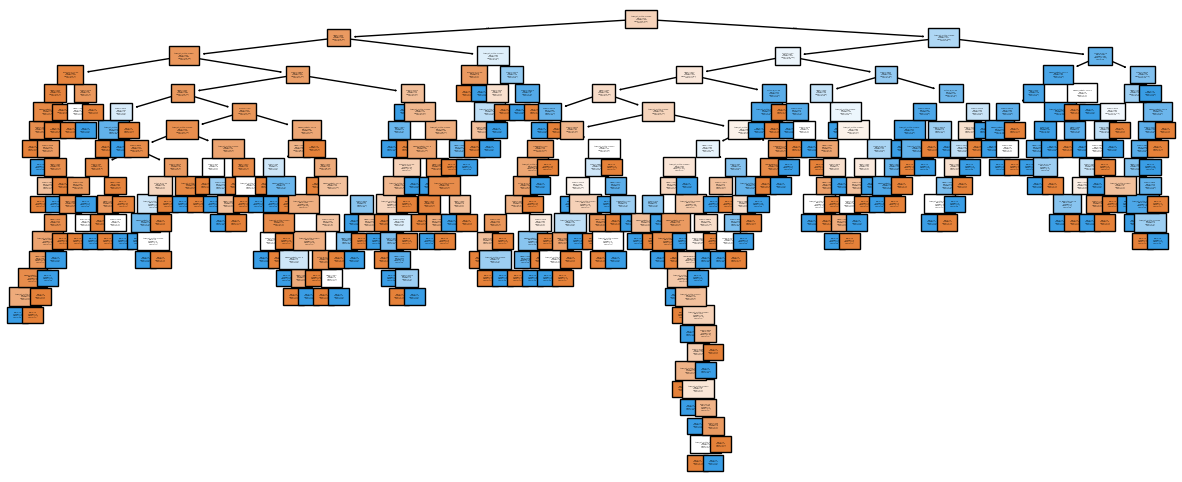

In [35]:
plt.figure(figsize = (15, 6))

plot_tree(arvore, 
          filled = True,
          class_names = ['nao', 'sim'],
          fontsize = 1,
          feature_names = nome_colunas)

As caixas estão muito pequenas e nós **conseguimos identificar que a nossa árvore tomou muitas decisões até chegar no resultado final**. 

Uma coisa que mencionamos na parte de validação, quando separamos os dados de treino e teste, foi para que não ocorresse de o modelo memorizar o padrão dos dados. A intenção dessa separação é garantir que o nosso modelo aprenda com os dados, e não os decore.

A ideia é que o nosso modelo acerta 66% das vezes quando classifica em dados que ele não viu. Contudo, se verificarmos o resultado nos dados de treinamento utilizando o método score() e passando **x_treino e y_treino**, verificaremos qual é a taxa de acerto nestes dados de treinamento. 

In [36]:
arvore.score(x_treino, y_treino)

1.0

Temos que o resultado é de 100% (1.0). Ele comparou as colunas da base de dados até que cada valor das caixas finais fosse o resultado real da classificação.

Ao fazer isso para os dados de treinamento, **o modelo acaba por memorizar esse padrão e tentar aplicá-lo nos dados de teste**.

Para corrigir esse problema que acontece com a árvore de decisão, temos que passar uma **profundidade máxima** para o algoritmo de árvore. Queremos que a árvore tome decisões, mas não ao ponto de esgotar os dados de treinamento. A árvore tem que tomar decisões que abranjam grande parte dos dados, mas que não precisam necessariamente corresponder exatamente à classificação feita nos dados de treinamento.

Vamos adicionar um novo parâmetro ao algoritmo DecisionTreeClassifier(): o **max_depth = 3**. Isso **define que o algoritmo tomará 3 decisões até chegar no resultado final**. A partir deste ponto, a ideia é que as melhores decisões sejam tomadas para dividir a maior quantidade de dados possível, mas que apenas 3 decisões sejam tomadas.

In [37]:
arvore = DecisionTreeClassifier(max_depth = 3, random_state = 5)
arvore.fit(x_treino, y_treino)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",5
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current nod

Vamos avaliar agora o desempenho desse modelo, tanto nos dados de treino quanto nos dados de teste.

In [38]:
print(f'Dados de Treino: {arvore.score(x_treino, y_treino)}')
print(f'Dados de teste: {arvore.score(x_teste, y_teste)}')

Dados de Treino: 0.7613038906414301
Dados de teste: 0.7160883280757098


O resultado obtido no teste foi de 71,6%. Esse resultado melhorou em relação ao modelo inicial que rendeu 66%. Isso indica que **quando fazemos essa "poda" na árvore**, ao utilizar uma quantidade de profundidade máxima da árvore, **o modelo tentará entender melhor o padrão dos dados existentes** e não apenas decorar o resultado dos dados de treinamento. 

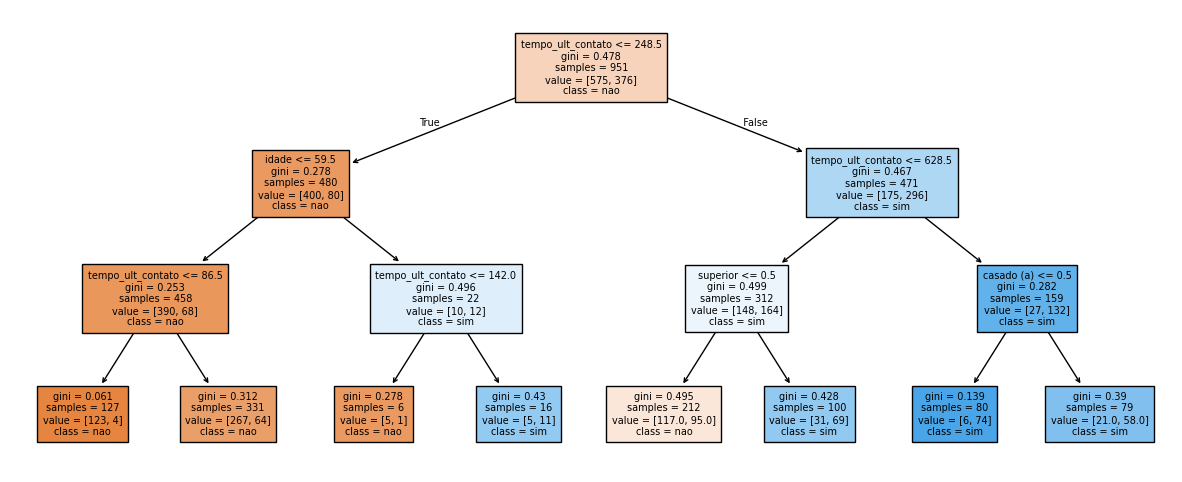

In [ ]:
plt.figure(figsize = (15, 6))
plot_tree(arvore, filled = True, class_names = ['nao', 'sim'], fontsize = 7, feature_names = nome_colunas);

Observe que no value, dentro dos blocos da árvore, temos "[123, 4]" no bloco à esquerda abaixo. Isso indica que temos 123 valores da classe "nao" e 4 da classe "sim". Apesar da existência de um erro de 4 valores da classe "sim" naquela classificação, ele tem a maioria dos valores da classe "nao". Então, ele determina que essa será a classificação para esses dados. 

## Seleção de Modelos

Agora, vamos utilizar um outro algoritmo para fazer essa classificação e conseguir comparar os resultados e ver qual algoritmo se sai melhor em classificar os clientes que estão aderindo ou não ao investimento da campanha de marketing do banco.

#### KNN

O princípio fundamental do KNN é de que "**coisas semelhantes estão próximas umas das outras**".

Este algoritmo, ao invés de tomar as decisões com base na comparação dos valores das colunas, como é na árvore de decisão, **realizará um cálculo de distância entre os elementos da base de dados**. Como exemplo, ele vai pegar o primeiro registro da base de dados, calcular a distância desse elemento para o segundo elemento da base de dados e assim por diante.

Por exemplo, na primeira linha, a terceira, quarta e a sétima linha da base de dados têm uma distância mais próxima da primeira. O algoritmo vai avaliar a classificação desses três elementos mais próximos e aquele que apresentar a maioria, por exemplo, se no terceiro, quarto tem a classificação de "não" e no sétimo tem a classificação de "sim", a maioria teve uma classificação de "não". Então, por analogia, o algoritmo deduz que o primeiro registro também deveria ter a mesma classificação. Essa é a regra utilizada pelo algoritmo KNN.

Porém, nesse cálculo de distância há um problema na nossa base de dados. **Caso a escala das variáveis seja muito diferente, esse cálculo de distância será influenciado**.

Por isso, nesses tipos de algoritmos que calculam distâncias, teremos que fazer um tratamento adicional para transformar a escala das variáveis para toda a mesma escala, entre 0 e 1. Dessa maneira, obteremos a influência da variável para obter o resultado e não simplesmente o valor dela ser maior e isso influenciar no cálculo da distância. A transformação que faremos na nossa base de dados é utilizando **MinMaxScaler**.

In [40]:
from sklearn.preprocessing import MinMaxScaler

In [41]:
normalizacao = MinMaxScaler()
x_treino_normalizado = normalizacao.fit_transform(x_treino)

Para visualizar o resultado, é interessante **transformar os dados em um DataFrame**, pois no processo de transformação esses **dados ficam em um array**, o que dificulta a visualização das informações.

In [42]:
pd.DataFrame(x_treino_normalizado)

,0,1,2,3,4,5,6,7,8,9,10,11
0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.205882,0.065564,0.123734,0.032258
1,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.147059,0.045792,0.396527,0.032258
2,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.338235,0.076036,0.335022,0.000000
3,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.573529,0.062866,0.315123,0.000000
4,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.338235,0.148380,0.065847,0.129032
...,...,...,...,...,...,...,...,...,...,...,...,...
946,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.191176,0.044265,0.246382,0.129032
947,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.205882,0.028043,0.275687,0.032258
948,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.323529,0.042952,0.024964,0.129032
949,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.176471,0.042810,0.023878,0.000000


In [43]:
from sklearn.neighbors import KNeighborsClassifier

In [44]:
knn = KNeighborsClassifier()
knn.fit(x_treino_normalizado, y_treino)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


Aqui, por padrão, ele seleciona o K, esse valor de K, é a quantidade de vizinhos mais próximos. Por padrão, é o valor 3.

Vamos avaliar o desempenho desse modelo e precisaremos passar os dados de teste. Mas os dados de teste não passaram pelo processo de normalização. Como o modelo aprendeu o padrão dos dados em dados entre 0 e 1, também precisará avaliar o desempenho usando dados que estejam nessa mesma escala, para não ocorrer nenhum problema.

In [45]:
x_teste_normalizado = normalizacao.transform(x_teste)

Fizemos o fit_transform anteriormente nos **dados de treino**, porque a partir do padrão dos dados de treino, **foi feito o processo de transformação, ele se ajustou e transformou**. Agora, vamos aplicar nos **dados de teste somente a transformação**. Ele não precisa aprender novamente qual é o valor mínimo e máximo dos dados. Ele simplesmente fará aquele cálculo e transformará os dados.

In [46]:
knn.score(x_teste_normalizado, y_teste)

0.6876971608832808

In [47]:
print(f'Acurácia Dummy: {dummy.score(x_teste, y_teste)}')
print(f'Acurácia Árvore: {arvore.score(x_teste, y_teste)}')
print(f'Acurácia KNN: {knn.score(x_teste_normalizado, y_teste)}')

Acurácia Dummy: 0.6025236593059937
Acurácia Árvore: 0.7160883280757098
Acurácia KNN: 0.6876971608832808


O modelo de árvore, por ser o que possui a taxa mais próxima de 1 (ou 100%), ou seja, o que apresenta o melhor desempenho, é o que vamos selecionar e utilizar no sistema do banco.

O próximo passo é selecionar este modelo e utilizar em um ambiente externo. Para isso, vamos precisar armazenar esse modelo em um arquivo utilizando a biblioteca Pickle.

In [ ]:
import pickle

Vamos armazenar também o modelo de OneHotEncoder que é o modelo de transformação. Isso porque, no sistema original, os dados estão em um formato diferente do que utilizamos. Portanto, **precisamos armazenar as transformações que fizemos para serem aplicadas em novos dados**.

In [49]:
with open('modelo_onehotenc.pkl', 'wb') as arquivo:
    pickle.dump(one_hot, arquivo)

Então, **.pkl é o tipo de arquivo que a gente vai armazenar**, que é o pickle. O **"wb" indica que vamos escrever bytes**, ou seja, armazenar um arquivo de bytes.

Vamos fazer a mesma coisa para o modelo de árvore.

In [50]:
with open('modelo_arvore.pkl', 'wb') as arquivo:
    pickle.dump(arvore, arquivo)

Agora, que já temos os modelos armazenados, poderemos aplicá-los em um novo dado que está no sistema do banco.

 Lembrando que precisamos transformar esse novo dado com o OneHotEncoder antes de fazer a classificação.

In [ ]:
novo_dado = {
    'idade': [45],
    'estado_civil':['solteiro (a)'],
    'escolaridade':['superior'],
    'inadimplencia': ['nao'],
    'saldo': [23040],
    'fez_emprestimo': ['nao'],
    'tempo_ult_contato': [800],
    'numero_contatos': [4]
}

novo_dado = pd.DataFrame(novo_dado)
novo_dado


,idade,estado_civil,escolaridade,inadimplencia,saldo,fez_emprestimo,tempo_ult_contato,numero_contatos
0,45,solteiro (a),superior,nao,23040,nao,800,4


Podemos utilizar o modelo de árvore e, apenas para exemplificar, podemos fazer a leitura do arquivo pkl utilizando a biblioteca pandas.

In [53]:
modelo_one_hot = pd.read_pickle('modelo_onehotenc.pkl')
modelo_arvore = pd.read_pickle('modelo_arvore.pkl')

Repare que, se usarmos diretamente o **modelo_arvore.predict(novo_dado)** para fazer a previsão desses novos dados, haverá um erro, pois os dados não estão transformados.

In [54]:
novo_dado = modelo_one_hot.transform(novo_dado)
modelo_arvore.predict(novo_dado)

array([1])

Vemos que o resultado do modelo de árvore, retorna um array com o valor 1. Isso indica que esse novo dado que utilizamos, esse cliente **aderirá à campanha de marketing, ele investirá**. Com base em nosso modelo de árvore de decisão.